Training RNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 101ms/step - accuracy: 0.6536 - loss: 0.6120 - val_accuracy: 0.5814 - val_loss: 0.6637
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.7660 - loss: 0.4789 - val_accuracy: 0.8056 - val_loss: 0.4594
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.8840 - loss: 0.2811 - val_accuracy: 0.6880 - val_loss: 0.6394
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.9628 - loss: 0.1092 - val_accuracy: 0.7334 - val_loss: 0.6944
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9937 - loss: 0.0279 - val_accuracy: 0.7272 - val_loss: 0.8712
Training LSTM...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 290ms/step - accuracy: 0.7964 - loss: 0.4338 - val_accuracy: 0.8510 - val_loss: 0.3566
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 285ms/step - accuracy: 0.8826 - loss: 0.2889 - val_accuracy: 0.8514 - val_loss: 0.3498
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 282ms/step - accuracy: 0.9262 - loss: 0.1

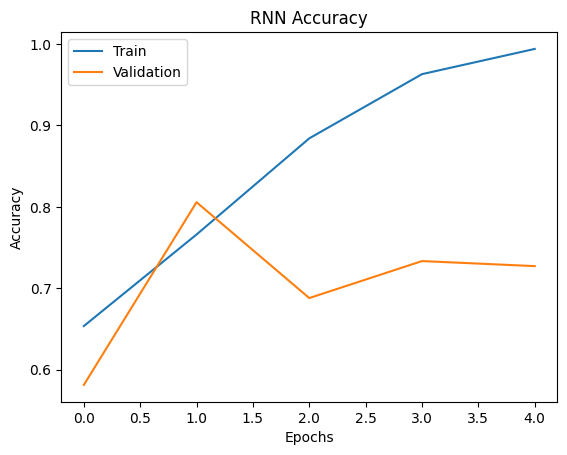

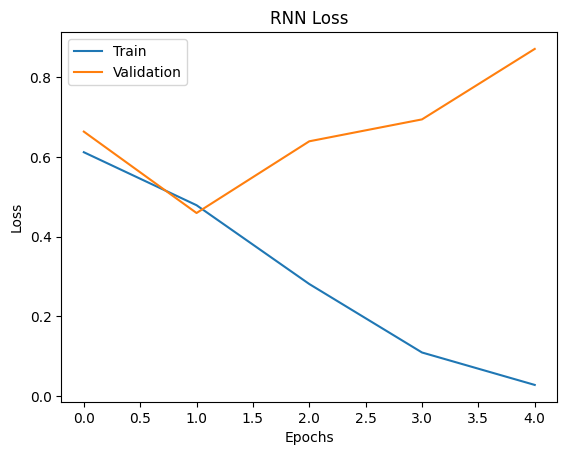

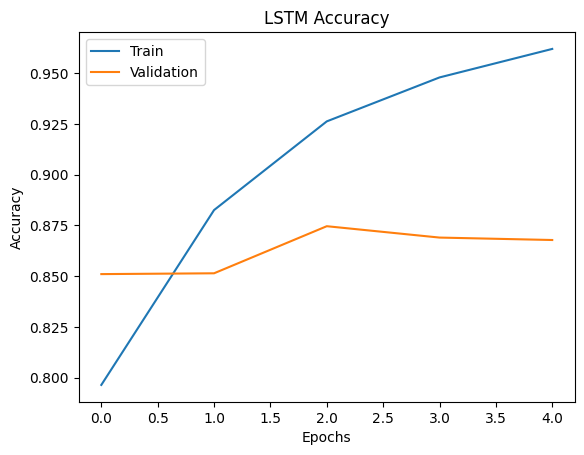

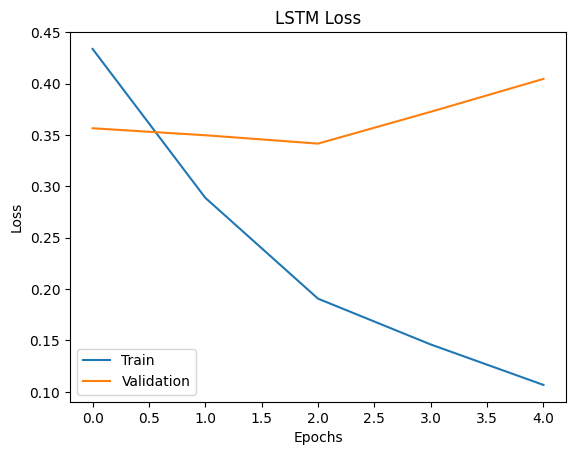

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step
RNN Report:
               precision    recall  f1-score   support

           0       0.73      0.70      0.72     12500
           1       0.71      0.74      0.73     12500

    accuracy                           0.72     25000
   macro avg       0.72      0.72      0.72     25000
weighted avg       0.72      0.72      0.72     25000

LSTM Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86     12500
           1       0.88      0.83      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report

# Load dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding sequences
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# -------------------------------
# RNN MODEL
# -------------------------------
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Training RNN...")
rnn_history = rnn_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# -------------------------------
# LSTM MODEL
# -------------------------------
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Training LSTM...")
lstm_history = lstm_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# -------------------------------
# PLOTS
# -------------------------------
import matplotlib.pyplot as plt

# RNN Accuracy
plt.figure()
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title('RNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# RNN Loss
plt.figure()
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.title('RNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# LSTM Accuracy
plt.figure()
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# LSTM Loss
plt.figure()
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# -------------------------------
# EVALUATION
# -------------------------------
rnn_pred = (rnn_model.predict(X_test) > 0.5).astype("int32")
lstm_pred = (lstm_model.predict(X_test) > 0.5).astype("int32")

print("RNN Report:\n", classification_report(y_test, rnn_pred))
print("LSTM Report:\n", classification_report(y_test, lstm_pred))